In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [21]:
print(df.dtypes)

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

In [22]:
df['Дата'] = pd.to_datetime(df['Дата'])
print(df.dtypes)

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Сгруппируйте данные по дате, посчитайте количество продаж

In [23]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [24]:
print(grouped_df.head())

        Дата  Количество
0 2018-01-04        3734
1 2018-01-05        3643
2 2018-01-06        3193
3 2018-01-07        3298
4 2018-01-09        4055


Нарисуйте график продаж у `grouped_df`

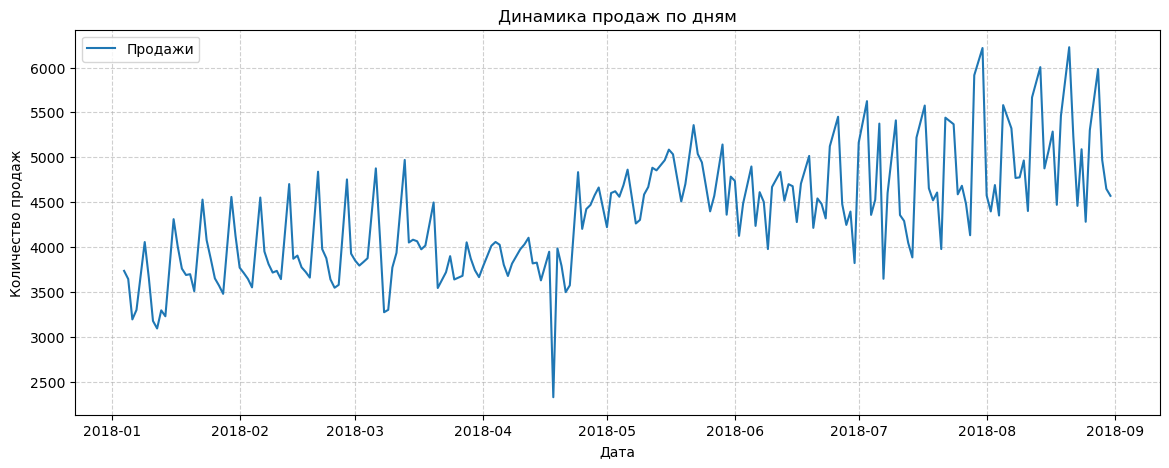

In [26]:
plt.figure(figsize=(14, 5))
plt.plot(grouped_df['Дата'], grouped_df['Количество'], color='#1f77b4', linewidth=1.5, label='Продажи')
plt.title('Динамика продаж по дням', fontsize=12)
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
# Данные графика затрагиывают данные с Января 2018 года, по Августа 2018 года, судя по динамике у нас наблюдается хороший uptrend, 
# а примерно к Маю, объем продаж увеличился на 20 + процентов


Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [28]:
max_outlier = df.loc[df['Количество'].idxmax()]
print(max_outlier)

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [30]:
wed_summer_wh3 = df[
    (df['Склад'] == 3) & 
    (df['Дата'].dt.dayofweek == 2) & 
    (df['Дата'].dt.month.isin([6, 7, 8]))
]
top_product = wed_summer_wh3.groupby('Номенклатура')['Количество'].sum().idxmax()
top_product_qty = wed_summer_wh3.groupby('Номенклатура')['Количество'].sum().max()

print(f"Топ товар: {top_product} (Продано: {top_product_qty} шт.)")

Топ товар: product_1 (Продано: 2267 шт.)


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

Первые 5 строк объединенной таблицы:
        Дата  Количество продаж        T
0 2018-01-04               3734 -14.0750
1 2018-01-05               3643 -16.8625
2 2018-01-06               3193 -13.3000
3 2018-01-07               3298 -12.7500
4 2018-01-09               4055  -6.2500


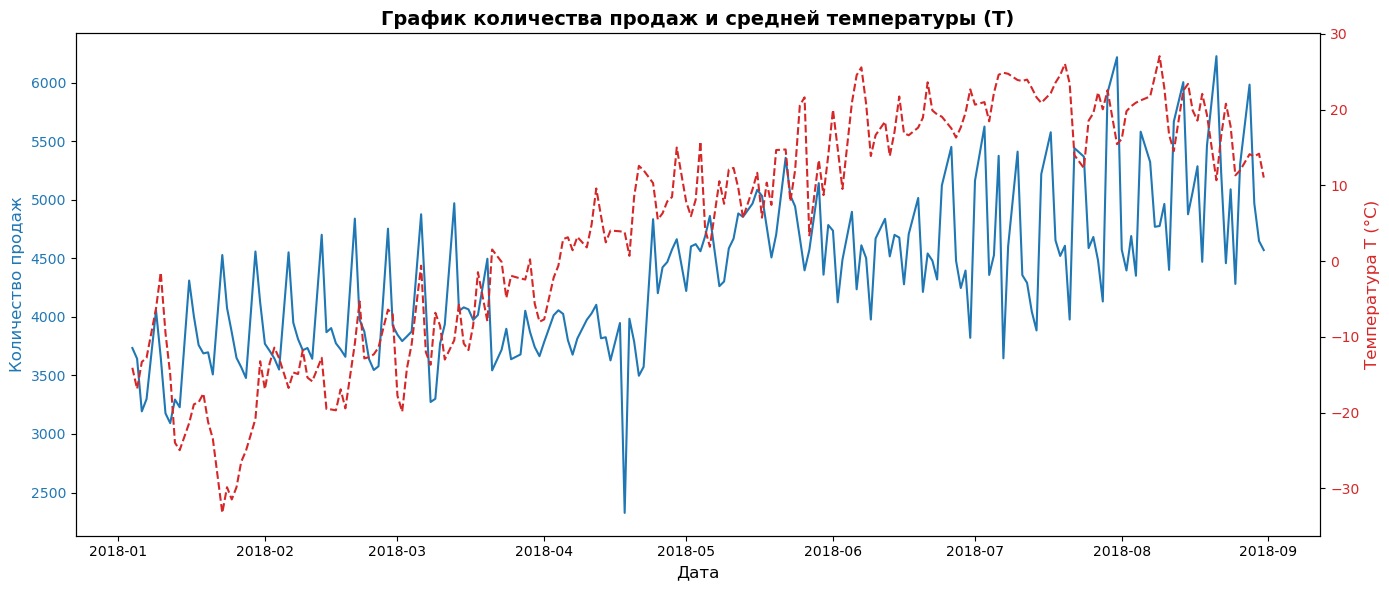

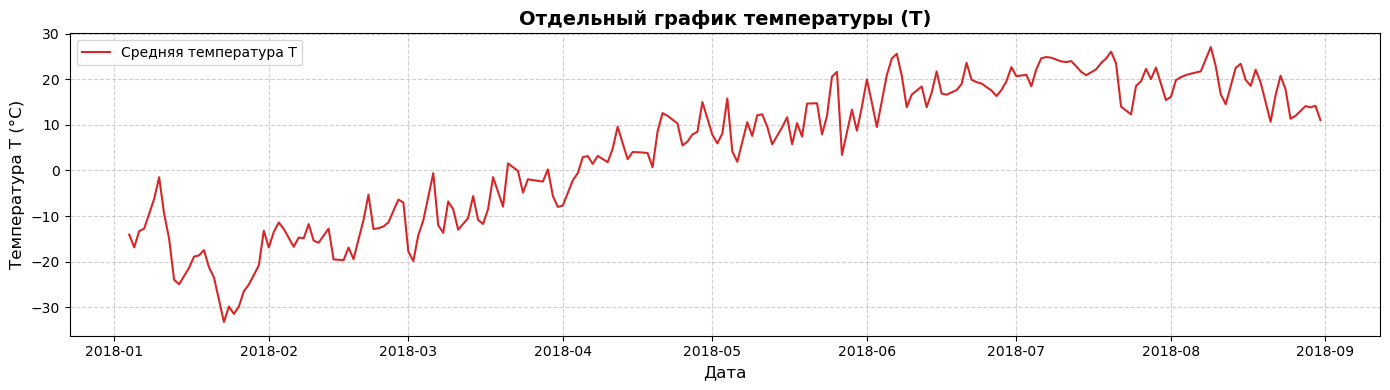

In [32]:
# Тут я читаю скаченный файл погоды (название не очень, но я решил не менять)
weather_filename = '35188.04.01.2018.31.08.2018.1.0.0.ru.ansi.00000000.csv'

weather_df = pd.read_csv(
    weather_filename, 
    skiprows=6, 
    sep=';', 
    encoding='cp1251', 
    index_col=False
)

# 2. Переводим дата/время и температуру T в числовой формат
weather_df['Дата'] = pd.to_datetime(weather_df['Местное время в Астане'], format='%d.%m.%Y %H:%M')
weather_df['Дата_день'] = weather_df['Дата'].dt.floor('D')
weather_df['T'] = pd.to_numeric(weather_df['T'], errors='coerce')

# 3. Находим ср. температуру T за день
daily_weather = weather_df.groupby('Дата_день')['T'].mean().reset_index()
daily_weather.rename(columns={'Дата_день': 'Дата'}, inplace=True)

# 4. Объединим ка таблицу температуры с сгрупп. продажами grouped_df
merged_df = pd.merge(grouped_df, daily_weather, on='Дата', how='inner')
merged_df.rename(columns={'Количество': 'Количество продаж'}, inplace=True)

# Выведу первые строки объед. таблицы
print("Первые 5 строк объединенной таблицы:")
print(merged_df.head())

# 5. Совмещ. график продажи и Т y=['Кол.во продаж', 'T']
fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:blue'
ax1.set_xlabel('Дата', fontsize=12)
ax1.set_ylabel('Количество продаж', color=color, fontsize=12)
ax1.plot(merged_df['Дата'], merged_df['Количество продаж'], color=color, label='Количество продаж', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # Вторая ось Y для T
color = 'tab:red'
ax2.set_ylabel('Температура T (°C)', color=color, fontsize=12)
ax2.plot(merged_df['Дата'], merged_df['T'], color=color, linestyle='--', label='T (°C)', linewidth=1.5)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('График количества продаж и средней температуры (T)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# 6. Чисто график температуры
plt.figure(figsize=(14, 4))
plt.plot(merged_df['Дата'], merged_df['T'], color='tab:red', linewidth=1.5, label='Средняя температура T')
plt.title('Отдельный график температуры (T)', fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура T (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()